In [11]:
import pandas as pd
from data_analysis_utils import wpe_row, weighted_permutation_entropy
import swifter
import matplotlib.pyplot as plt
import numpy as np

In [3]:
ecg_test= pd.read_parquet('../data/data_storage/ecg_parquets/test_ecg.parquet')
ecg_train = pd.read_parquet('../data/data_storage/ecg_parquets/train_ecg.parquet')
ecg_val = pd.read_parquet('../data/data_storage/ecg_parquets/val_ecg.parquet')

ecg_df = pd.concat([ecg_test, ecg_train, ecg_val], axis=0).reset_index(drop=True)

harmonic_test= pd.read_parquet('../data/data_storage/harmonic_ou_parquets/test_harmonic.parquet')
harmonic_train = pd.read_parquet('../data/data_storage/harmonic_ou_parquets/train_harmonic.parquet')
harmonic_val = pd.read_parquet('../data/data_storage/harmonic_ou_parquets/val_harmonic.parquet')

harmonic_df = pd.concat([harmonic_test, harmonic_train, harmonic_val], axis=0).reset_index(drop=True)

ou_test= pd.read_parquet('../data/data_storage/harmonic_ou_parquets/test_ou.parquet')
ou_train = pd.read_parquet('../data/data_storage/harmonic_ou_parquets/train_ou.parquet')
ou_val = pd.read_parquet('../data/data_storage/harmonic_ou_parquets/val_ou.parquet')

ou_df = pd.concat([ou_test, ou_train, ou_val], axis=0).reset_index(drop=True)

sp500_test= pd.read_parquet('../data/data_storage/sp500_parquets/test_sp500.parquet')
sp500_train = pd.read_parquet('../data/data_storage/sp500_parquets/train_sp500.parquet')
sp500_val = pd.read_parquet('../data/data_storage/sp500_parquets/val_sp500.parquet')

sp500_df = pd.concat([sp500_test, sp500_train, sp500_val], axis=0).reset_index(drop=True)

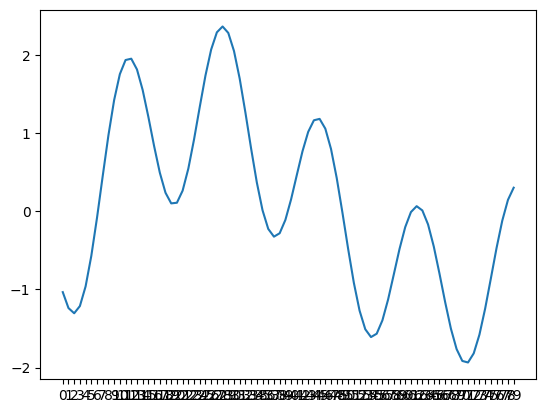

In [9]:
plt.plot(harmonic_df.loc[10])

In [13]:
weighted_permutation_entropy(harmonic_df.loc[10])

0.40323191443425366

In [16]:
harmonic_df.head(10).swifter.apply(wpe_row, axis=1)

Pandas Apply: 100%|██████████| 10/10 [00:00<00:00, 230.05it/s]


0    0.387318
1    0.484376
2    0.404072
3    0.396202
4    0.393128
5    0.400145
6    0.388641
7    0.414217
8    0.809747
9    0.322907
dtype: float64

In [17]:
ecg_wpe_series = ecg_df.swifter.apply(wpe_row, axis=1)
harmonic_wpe_series = harmonic_df.swifter.apply(wpe_row, axis=1)
ou_wpe_series = ou_df.swifter.apply(wpe_row, axis=1)
sp500_wpe_series = sp500_df.swifter.apply(wpe_row, axis=1)

Dask Apply: 100%|██████████| 17/17 [00:39<00:00,  2.33s/it]


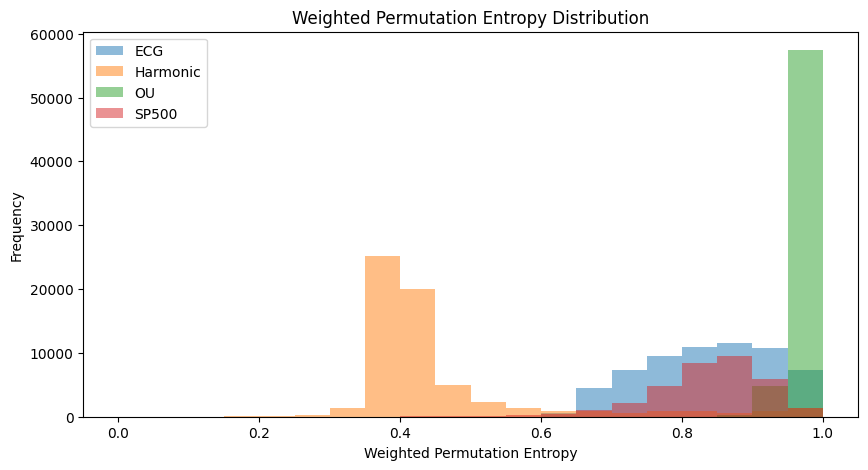

In [26]:
plt.figure(figsize=(10, 5))
# Define fixed bin edges from 0 to 1 with steps of 0.02
bins = np.arange(0, 1.02, 0.05)  # 0.02 is the bin size, going slightly over 1 to include all data

plt.hist(ecg_wpe_series, bins=bins, alpha=0.5, label='ECG')
plt.hist(harmonic_wpe_series, bins=bins, alpha=0.5, label='Harmonic')
plt.hist(ou_wpe_series, bins=bins, alpha=0.5, label='OU')
plt.hist(sp500_wpe_series, bins=bins, alpha=0.5, label='SP500')

plt.title('Weighted Permutation Entropy Distribution')
plt.xlabel('Weighted Permutation Entropy')
plt.ylabel('Frequency')
plt.legend()
plt.show()